> In machine learning, a learning curve (or training curve) plots the optimal value of a model's loss function for a training set against this loss function evaluated on a validation data(Test set) set with same parameters as produced the optimal function. 

> It is a tool to find out how much a machine model benefits from adding more training data and whether the estimator suffers more from a variance error or a bias error.

> Learning curves of model performance on the train and validation datasets can be used to diagnose an underfit, overfit, or well-fit model.

> Learning curves of model performance can be used to diagnose whether the train or validation datasets are not relatively representative of the problem domain.

> Generally, a learning curve is a plot that shows time or experience on the x-axis and learning or improvement on the y-axis.

> For example, if you were learning a musical instrument, your skill on the instrument could be evaluated and assigned a numerical score each week for one year. A plot of the scores over the 52 weeks is a learning curve and would show how your learning of the instrument has changed over time.

> It is more common to use a score that is minimizing, such as loss or error whereby better scores (smaller numbers) indicate more learning and a value of 0.0 indicates that the training dataset was learned perfectly and no mistakes were made.

>> Train Learning Curve: Learning curve calculated from the training dataset that gives an idea of how well the model is learning.

>> Validation Learning Curve: Learning curve calculated from a hold-out validation dataset that gives an idea of how well the model is generalizing.

It is common to create dual learning curves for a machine learning model during training on both the training and validation datasets.

> Optimization Learning Curves: Learning curves calculated on the metric by which the parameters of the model are being optimized, e.g. loss.

> Performance Learning Curves: Learning curves calculated on the metric by which the model will be evaluated and selected, e.g. accuracy.

In [2]:
'''
The extent to which ML model to be trained can be understood/better explained using Learning curve.

It can be plotted as 'various data size v/s accuracy' OR 'various data size v/s error'
'''

"\nThe extent to which ML model to be trained can be understood/better explained using Learning curve.\n\nIt can be plotted as 'various data size v/s accuracy' OR 'various data size v/s error'\n"

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [5]:
cancer = load_breast_cancer()

In [6]:
print(cancer.DESCR)

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

    :Number of Instances: 569

    :Number of Attributes: 30 numeric, predictive attributes and the class

    :Attribute Information:
        - radius (mean of distances from center to points on the perimeter)
        - texture (standard deviation of gray-scale values)
        - perimeter
        - area
        - smoothness (local variation in radius lengths)
        - compactness (perimeter^2 / area - 1.0)
        - concavity (severity of concave portions of the contour)
        - concave points (number of concave portions of the contour)
        - symmetry 
        - fractal dimension ("coastline approximation" - 1)

        The mean, standard error, and "worst" or largest (mean of the three
        largest values) of these features were computed for each image,
        resulting in 30 features.  For instance, field 3 is Mean Radius, f

In [7]:
X = cancer.data  # Input
y = cancer.target  # output

In [8]:
X.shape, y.shape

((569, 30), (569,))

# Draw Learning Curve:

In [9]:
from sklearn.model_selection import learning_curve

In [10]:
'''
learning_curve(
    estimator,
    X,
    y,
    *,
    groups=None,
    train_sizes=array([0.1  , 0.325, 0.55 , 0.775, 1.   ]),
    cv=None,
    scoring=None,
    exploit_incremental_learning=False,
    n_jobs=None,
    pre_dispatch='all',
    verbose=0,
    shuffle=False,
    random_state=None,
    error_score=nan,
    return_times=False,
)
'''

"\nlearning_curve(\n    estimator,\n    X,\n    y,\n    *,\n    groups=None,\n    train_sizes=array([0.1  , 0.325, 0.55 , 0.775, 1.   ]),\n    cv=None,\n    scoring=None,\n    exploit_incremental_learning=False,\n    n_jobs=None,\n    pre_dispatch='all',\n    verbose=0,\n    shuffle=False,\n    random_state=None,\n    error_score=nan,\n    return_times=False,\n)\n"

In [11]:
train_sizes, train_scores, test_scores = learning_curve(
    RandomForestClassifier(),
    X,
    y,
    cv = 10,
    scoring = 'accuracy',
    n_jobs = -1, #use all the cores in my laptop
    train_sizes = np.linspace(0.01,1,50),
    verbose = 1
)

# below we can see total 50 train sets are created.

[learning_curve] Training set sizes: [  5  15  25  36  46  56  67  77  87  98 108 118 129 139 149 159 170 180
 190 201 211 221 232 242 252 263 273 283 294 304 314 325 335 345 356 366
 376 387 397 407 418 428 438 449 459 469 480 490 500 511]


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    5.1s finished


In [12]:
train_sizes

array([  5,  15,  25,  36,  46,  56,  67,  77,  87,  98, 108, 118, 129,
       139, 149, 159, 170, 180, 190, 201, 211, 221, 232, 242, 252, 263,
       273, 283, 294, 304, 314, 325, 335, 345, 356, 366, 376, 387, 397,
       407, 418, 428, 438, 449, 459, 469, 480, 490, 500, 511])

In [13]:
train_scores

array([[1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ],
       [1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ],
       [1.        , 0.96      , 1.        , 1.        , 1.        ,
        0.96      , 0.96      , 1.        , 1.        , 1.        ],
       [1.        , 1.        , 0.97222222, 1.        , 0.97222222,
        1.        , 1.        , 1.        , 1.        , 0.97222222],
       [1.        , 1.        , 1.        , 0.97826087, 1.        ,
        0.97826087, 1.        , 1.        , 1.        , 1.        ],
       [1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ],
       [0.97014925, 1.        , 1.        , 1.        , 1.        ,
        0.98507463, 1.        , 1.        , 1.        , 1.        ],
       [1.        , 1.        , 1.       

In [14]:
test_scores

array([[0.37931034, 0.37931034, 0.36842105, 0.36842105, 0.36842105,
        0.36842105, 0.36842105, 0.375     , 0.375     , 0.375     ],
       [0.37931034, 0.37931034, 0.36842105, 0.36842105, 0.36842105,
        0.36842105, 0.36842105, 0.375     , 0.375     , 0.375     ],
       [0.37931034, 0.67241379, 0.77192982, 0.71929825, 0.92982456,
        0.8245614 , 0.57894737, 0.51785714, 0.75      , 0.78571429],
       [0.37931034, 0.84482759, 0.66666667, 0.71929825, 0.92982456,
        0.66666667, 0.71929825, 0.66071429, 0.66071429, 0.5       ],
       [0.48275862, 0.89655172, 0.63157895, 0.70175439, 0.73684211,
        0.57894737, 0.77192982, 0.58928571, 0.69642857, 0.60714286],
       [0.84482759, 0.82758621, 0.78947368, 0.80701754, 0.84210526,
        0.84210526, 0.87719298, 0.75      , 0.73214286, 0.80357143],
       [0.86206897, 0.84482759, 0.92982456, 0.8245614 , 0.89473684,
        0.87719298, 0.87719298, 0.80357143, 0.76785714, 0.875     ],
       [0.89655172, 0.84482759, 0.9649122

In [15]:
# Get Train Mean

train_mean = np.mean(train_scores, axis = 1)
train_mean

array([1.        , 1.        , 0.988     , 0.99166667, 0.99565217,
       1.        , 0.99552239, 1.        , 0.99770115, 0.99489796,
       0.99259259, 0.99237288, 0.99844961, 0.99640288, 0.9966443 ,
       0.99622642, 0.99647059, 0.99722222, 0.99684211, 0.99552239,
       0.99668246, 0.99683258, 0.99655172, 0.99834711, 0.99642857,
       0.99771863, 0.9970696 , 0.99646643, 0.9952381 , 0.99901316,
       0.99522293, 0.99661538, 0.99701493, 0.99797101, 0.99719101,
       0.99808743, 0.99734043, 0.99793282, 0.99672544, 0.9972973 ,
       0.99952153, 0.99719626, 0.99748858, 0.99755011, 0.99803922,
       0.99616205, 0.99770833, 0.99836735, 0.9978    , 0.99765166])

In [16]:
# Get Train STD ie how far score is deviating from centered mean

train_std = np.std(train_scores, axis = 1)
train_std

array([0.        , 0.        , 0.0183303 , 0.01272938, 0.00869565,
       0.        , 0.0095569 , 0.        , 0.0045977 , 0.00684511,
       0.006929  , 0.0059322 , 0.00310078, 0.00482605, 0.00450215,
       0.00417186, 0.00390191, 0.00447903, 0.00349118, 0.00469352,
       0.00217184, 0.00289734, 0.00322557, 0.00274101, 0.00277778,
       0.00252215, 0.00457509, 0.00316052, 0.00346872, 0.00210629,
       0.00356062, 0.00215385, 0.00266993, 0.00185598, 0.00280899,
       0.00213395, 0.00168206, 0.00225266, 0.00253145, 0.00279062,
       0.00095694, 0.00228924, 0.00238363, 0.00185003, 0.00265938,
       0.00282868, 0.00196541, 0.00122449, 0.0014    , 0.00170603])

In [17]:

# Get Test Mean

test_mean = np.mean(test_scores, axis = 1)
test_mean

array([0.3725726 , 0.3725726 , 0.6929857 , 0.67473209, 0.66932201,
       0.81160228, 0.85568339, 0.87849257, 0.87304468, 0.91023356,
       0.91029513, 0.90499957, 0.91392706, 0.92442313, 0.93319614,
       0.91894283, 0.91721869, 0.93676865, 0.92774933, 0.92799348,
       0.93335386, 0.91019899, 0.93495484, 0.94732845, 0.95099386,
       0.92260824, 0.94212579, 0.94551357, 0.94206529, 0.9437581 ,
       0.92276381, 0.94037248, 0.93492244, 0.94212687, 0.95450048,
       0.94582037, 0.94034115, 0.95440973, 0.95973555, 0.95813348,
       0.95090096, 0.94388234, 0.95976471, 0.94739111, 0.94748401,
       0.94575663, 0.95089988, 0.9509917 , 0.96152018, 0.95973447])

In [18]:
# Get Test STD

test_std = np.std(test_scores, axis = 1)
test_std

array([0.00441189, 0.00441189, 0.15318901, 0.14707323, 0.1109853 ,
       0.04266877, 0.04458346, 0.05200618, 0.06153505, 0.03124409,
       0.03993493, 0.04449021, 0.03162601, 0.04441484, 0.03989694,
       0.04567898, 0.05779495, 0.03344839, 0.03230208, 0.04353906,
       0.02957025, 0.05517819, 0.03223082, 0.035703  , 0.03373027,
       0.03935461, 0.0242888 , 0.01457923, 0.027049  , 0.03112626,
       0.02449195, 0.03216262, 0.04197402, 0.02999653, 0.03396307,
       0.03881417, 0.02611019, 0.02074595, 0.03570588, 0.03626786,
       0.03377345, 0.02983895, 0.03284932, 0.03112087, 0.04040861,
       0.04333871, 0.03721949, 0.03357756, 0.02645632, 0.03009401])

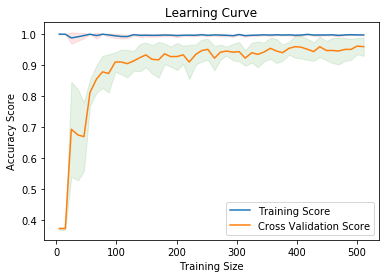

In [19]:
plt.plot(train_sizes, train_mean, label = 'Training Score')
plt.plot(train_sizes, test_mean, label = 'Cross Validation Score')


plt.fill_between(train_sizes, (train_mean - train_std),(train_mean + train_std), alpha=0.1,color="r")    

# train_mean - train_std i.e left side of the centered mean
# train_mean + train_std i.e right side of the centered mean

plt.fill_between(train_sizes, (test_mean - test_std),(test_mean + test_std), alpha=0.1, color="g")

plt.title('Learning Curve')
plt.xlabel('Training Size')
plt.ylabel('Accuracy Score')
plt.legend (loc = 'best')

# we can see that as the data size is increased the accuracy from testing has increased and at later stage (at around
# 250 data size) it has got saturated. After that even if we increased the the data there is no much progress
# in accuracy so at after some point there is no need to put effort to bring more and more data. If we have to still
# achieve some more better accuracy we need to check for other optinos like Feature Engineering, Feature Scaling,
# hyper parameter tuning etc.